In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the raw data
df = pd.read_csv("../data/raw/btc_usdt_1h.csv", parse_dates=["timestamp"])

print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nFirst rows:")
df.head()

Shape: (32124, 6)

Data types:
timestamp    datetime64[us]
open                float64
high                float64
low                 float64
close               float64
volume              float64
dtype: object

First rows:


,timestamp,open,high,low,close,volume
0,2023-01-01 00:00:00,16541.77,16545.70,16508.39,16529.67,4364.83570
1,2023-01-01 01:00:00,16529.59,16556.80,16525.78,16551.47,3590.06669
2,2023-01-01 02:00:00,16551.47,16559.77,16538.14,16548.19,3318.84038
3,2023-01-01 03:00:00,16548.19,16548.19,16518.21,16533.04,4242.08050
4,2023-01-01 04:00:00,16533.04,16535.97,16511.92,16521.85,4285.00909


In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check for duplicate timestamps
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate timestamps:", df["timestamp"].duplicated().sum())

# Check the time range and expected vs actual row count
print("\nDate range:", df["timestamp"].min(), "to", df["timestamp"].max())

# Expected number of hourly candles in this range
expected_hours = pd.date_range(start=df["timestamp"].min(), end=df["timestamp"].max(), freq="h")
print("Expected candles:", len(expected_hours))
print("Actual candles:", len(df))
print("Missing candles (gaps):", len(expected_hours) - len(df))

Missing values per column:
timestamp    0
open         0
high         0
low          0
close        0
volume       0
dtype: int64

Duplicate rows: 0
Duplicate timestamps: 0

Date range: 2023-01-01 00:00:00 to 2026-08-31 12:00:00
Expected candles: 32125
Actual candles: 32124
Missing candles (gaps): 1


In [6]:
# Find the exact missing timestamp(s)
missing_times = expected_hours.difference(df["timestamp"])
print("Missing timestamp(s):")
print(missing_times)

Missing timestamp(s):
DatetimeIndex(['2023-03-24 13:00:00'], dtype='datetime64[us]', freq='h')


In [7]:
# Set timestamp as index and reindex to fill the gap
df = df.set_index("timestamp").reindex(expected_hours)
df.index.name = "timestamp"

# Interpolate the missing row (linear interpolation between neighboring candles)
df = df.interpolate(method="linear")

# Reset index back to a normal column
df = df.reset_index()

# Verify the fix
print("Missing values after fix:")
print(df.isnull().sum())
print("\nRow count:", len(df))
print("\nCheck the filled row:")
print(df[df["timestamp"] == "2023-03-24 13:00:00"])

Missing values after fix:
timestamp    0
open         0
high         0
low          0
close        0
volume       0
dtype: int64

Row count: 32125

Check the filled row:
               timestamp       open       high      low     close      volume
1981 2023-03-24 13:00:00  28079.995  28166.505  27957.5  28034.53  4491.62009


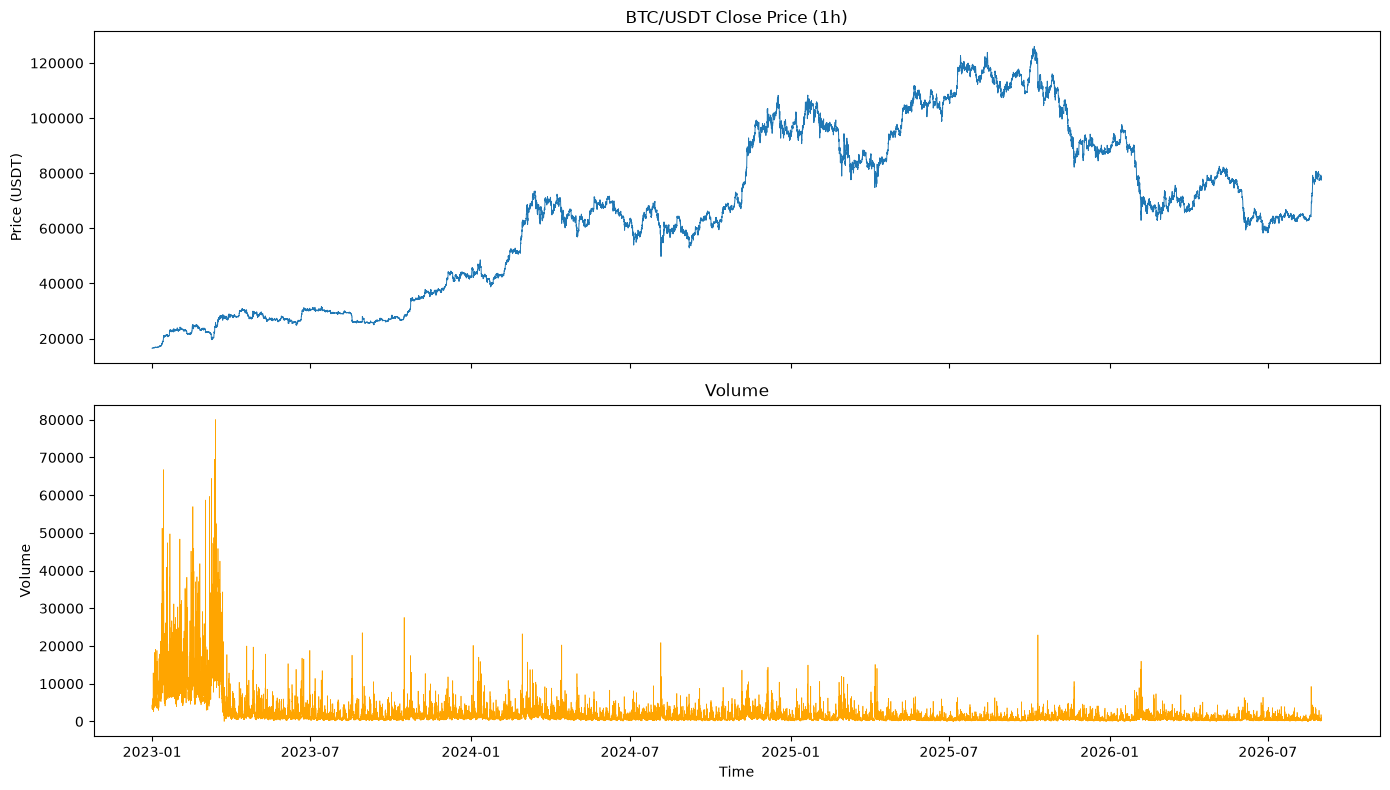

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df["timestamp"], df["close"], linewidth=0.7)
axes[0].set_title("BTC/USDT Close Price (1h)")
axes[0].set_ylabel("Price (USDT)")

axes[1].plot(df["timestamp"], df["volume"], linewidth=0.5, color="orange")
axes[1].set_title("Volume")
axes[1].set_ylabel("Volume")
axes[1].set_xlabel("Time")

plt.tight_layout()
plt.show()

In [9]:
# Compare average volume before and after March 2023
before = df[df["timestamp"] < "2023-04-01"]["volume"].mean()
after = df[df["timestamp"] >= "2023-04-01"]["volume"].mean()

print(f"Avg volume before Apr 2023: {before:.2f}")
print(f"Avg volume after Apr 2023: {after:.2f}")
print(f"Ratio: {before/after:.2f}x higher before")

Avg volume before Apr 2023: 12102.04
Avg volume after Apr 2023: 1189.33
Ratio: 10.18x higher before


In [10]:
# Save cleaned, gap-filled data to processed folder
output_path = "../data/processed/btc_usdt_1h_clean.csv"
df.to_csv(output_path, index=False)
print(f"Saved cleaned dataset: {len(df)} rows to {output_path}")

Saved cleaned dataset: 32125 rows to ../data/processed/btc_usdt_1h_clean.csv
